<a href="https://colab.research.google.com/github/supreeeethh/EliteTech/blob/main/Elite_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 198ms/step - accuracy: 0.3483 - loss: 1.8504 - val_accuracy: 0.4497 - val_loss: 1.5457
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 157s 201ms/step - accuracy: 0.5418 - loss: 1.2754 - val_accuracy: 0.4761 - val_loss: 1.5755
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 197ms/step - accuracy: 0.6251 - loss: 1.0602 - val_accuracy: 0.6458 - val_loss: 1.0199
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 197ms/step - accuracy: 0.6778 - loss: 0.9309 - val_accuracy: 0.5378 - val_loss: 1.4874
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 199ms/step - accuracy: 0.7095 - loss: 0.8293 - val_accuracy: 0.6660 - val_loss: 0.9935
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 152s 195ms/step - accuracy: 0.7412 - loss: 0.7495 - val_accuracy: 0.6638 - val_loss: 0.9818
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 195ms/step - accuracy: 0.7630 - loss: 0.6804 - val_accuracy: 0.7484 - 

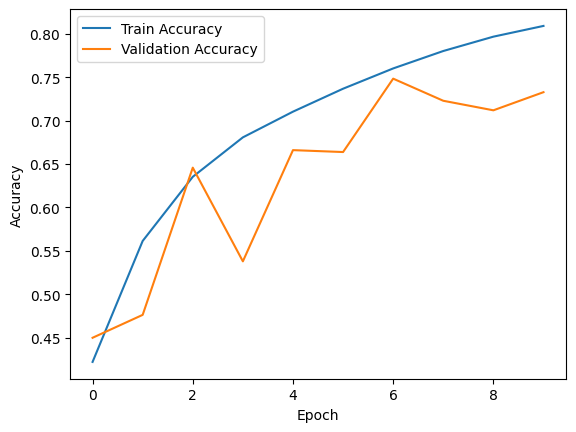

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step

Sample Prediction: cat


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape:", train_images.shape)
inputs = tf.keras.Input(shape=(32, 32, 3))

x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels)
)
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("\nTest Accuracy:", test_acc)
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

predictions = model.predict(test_images)
print("\nSample Prediction:", class_names[predictions[0].argmax()])